In [1]:
""" Implementation of the nmf example using alternating projections instead of douglas-rachford."""
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
import jax
from jax import numpy as jnp


In [20]:
""" Bilear projection using Newton's method. (from pjaxs library) """
newtonSteps = 10
def pos(m):
    m[m<0] = 0
    return m

def bilinear_proj(a, b, z, /):
    """Project onto bilinear function graph using Newton's method."""
    p = a @ b
    q = a @ a + b @ b
    def f(t):
        return ((1 + t**2) * p + t * q) / (1 - t**2) ** 2 - z + t
 
    f_prime = jax.grad(f)

    def newton_step(t):
        return t - f(t) / f_prime(t)

    t = jax.lax.fori_loop(0, newtonSteps, lambda _, t: newton_step(t), 0.0, unroll=False)

    a_new = (a + t * b) / (1 - t**2)
    b_new = (b + t * a) / (1 - t**2)

    return a_new, b_new


ValueError: Negative values in data passed to NMF initialization.

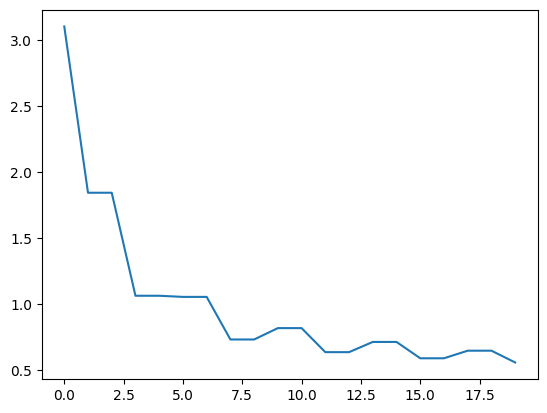

In [ ]:
### nmf using alternating projections   
samples=3

dimension=3
rankW = 3
Y = np.random.rand(dimension, samples)
W_A = np.random.rand(dimension, rankW )
X_A = np.random.rand(rankW, samples )
X_A = np.maximum(X_A, 0)
W_i = np.zeros((samples,dimension, rankW))
X_i = np.zeros((samples, rankW, samples))

### perform nmf
norm = []
for iter in range(100):
    norm.append(np.linalg.norm( W_A @ X_A - Y))
    for k in range(samples):
        x = np.zeros_like(X_A)
        w = np.zeros_like(W_A)

        ## projection of w on non-negative orthant
        w = pos(W_A)
        ## projection of x on non-negative orthant
        x[:,k] =  np.maximum(X_A[:,k],0)      
        tempx = np.zeros((rankW, rankW))
        for i in range(rankW):
            w[i,:],tempx[:,i] = bilinear_proj(w[i,:],x[:,k], Y[i,k])
        x = np.mean(tempx, axis=1)
        W_i[k,:,:] = w
        X_i[k,:,:] = x
    W_A = np.mean(W_i, axis=0)
    X_A = np.mean(X_i, axis=1)
                
    
import matplotlib.pyplot as plt
plt.plot(norm)
model = NMF(n_components=3, init='random', random_state=0)
W = model.fit_transform(Y)
H = model.components_
print(min(norm), np.argmin(norm))
print(np.linalg.norm(W @ H - Y))
print(W_A )
print(X_A)

In [ ]:
### nmf using douglas -rachford 
samples=3

dimension=3
rankW = 3
Y = np.random.rand(dimension, samples)
W_A = np.random.rand(dimension, rankW )
X_A = np.random.rand(rankW, samples )
X_A = np.maximum(X_A, 0)
W_i = np.zeros((samples,dimension, rankW))
X_i = np.zeros((samples, rankW, samples))

### perform nmf
norm = []
for iter in range(100):
    norm.append(np.linalg.norm( W_A @ X_A - Y))
    for k in range(samples):
        x = np.zeros_like(X_A)
        w = np.zeros_like(W_A)

        ## reflection of w on non-negative orthant
        w = 2*pos(W_A) - W_A
        ## reflection of x on non-negative orthant
        x[:,k] =  2*np.maximum(X_A[:,k],0) - X_A[:,k]
        tempx = np.zeros((rankW, rankW))
        for i in range(rankW):
            
            pwi,tempx[:,i] = bilinear_proj(w[i,:],x[:,k], Y[i,k])
            w[i,:] = 2*pwi - w[i,:]
            tempx[:,i] = 2*tempx[:,i] - x[:,k]

        x = np.mean(tempx, axis=1)
        
        W_i[k,:,:] = 0.5*(w + W_A)
        X_i[k,:,:] = 0.5*(x + X_A[:,k])
    W_A = np.mean(W_i, axis=0)
    X_A = np.mean(X_i, axis=1)
                
import matplotlib.pyplot as plt
plt.plot(norm)
model = NMF(n_components=3, init='random', random_state=0)
W = model.fit_transform(Y)
H = model.components_
print(min(norm), np.argmin(norm))
print(np.linalg.norm(W @ H - Y))
print(W_A )
print(X_A)